# Understanding Your Data
### Systematic Inspection, Health Checks, and Statistical Diagnostics for Machine Learning

---

### Scope & Focus of This Notebook
- **Primary Topic**: Understanding the structure, data types, data quality, summary statistics, cardinality, and pairwise linear correlations of a tabular dataset.
- **What You Will Learn**:
  1. Structural inspection: Dimensionality (`shape`), feature names (`columns`), storage types (`dtypes`), and memory summaries (`info()`).
  2. Statistical summaries: Numerical five-number summaries and categorical frequency distributions (`describe()`).
  3. Data quality health checks: Quantifying nullity (`isnull().sum()`) and duplicate rows (`duplicated().sum()`).
  4. Cardinality analysis: Low vs high cardinality (`nunique()`, `value_counts(normalize=True)`).
  5. Feature relationships: Linear correlation matrices (`corr()`) and visual heatmaps (`sns.heatmap()`).
  6. Critical thinking: Why correlation does not imply causation.
- **What We Will NOT Cover Here**:
  - Detailed single-variable distribution plots (histograms, KDEs, box plots) are covered in **`Module 02: EDA — 01_Univariate_Analysis`**.
  - Two-variable interactions and multi-variable faceting belong to **`02_Bivariate_Analysis`** and **`03_Multivariate_Analysis`**.
  - Automated report generation is covered in **`04_Pandas_Profiling`**.
  - Preprocessing, scaling, and categorical encoding belong to **`Module 03: Feature Engineering`**.

---

## 1. Setup & Environment Verification

### What are we doing?
We import the required data manipulation (`pandas`, `numpy`) and visualization libraries (`matplotlib.pyplot`, `seaborn`) and load the Titanic dataset using robust relative path checking.

#### What do these libraries do here?
- `pandas`: Tabular data structures and data inspection methods.
- `numpy`: Numerical calculations and array manipulations.
- `matplotlib.pyplot` & `seaborn`: Visualization styling and correlation heatmap plotting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Visual styling
sns.set_theme(style="whitegrid")

# Robust path resolution
data_path = '../../data/titanic.csv' if os.path.exists('../../data/titanic.csv') else 'data/titanic.csv'
df = pd.read_csv(data_path)

print(f"Loaded dataset: {data_path}")
print(f"Dataset shape:  {df.shape}")


Loaded dataset: ../../data/titanic.csv
Dataset shape:  (891, 12)


## 2. Structural Inspection: `shape`, `columns`, and `dtypes`

### What are we doing?
We examine the dimensions, column names, and raw data types of the loaded dataset.

#### What does each property do?
- `df.shape`: Returns a tuple `(n_rows, n_columns)`.
- `df.columns`: Returns an `Index` object containing all column header names.
- `df.dtypes`: Returns a `Series` indicating the storage data type of each feature.

#### Why are we doing this?
Before computing any math, we must verify the size of our feature matrix, ensure column names do not contain hidden spaces, and check if numerical features were parsed as numbers rather than text strings.

#### What is the implication?
The Titanic dataset contains **891 rows** (passengers) and **12 columns** (features including target `Survived`). Features span integers (`int64`), floating-point numbers (`float64`), and text strings (`object`).


In [2]:
# Inspect shape, columns, and data types
print("--- 1. Dataset Dimensionality ---")
print(f"Rows (Samples):   {df.shape[0]}")
print(f"Columns (Features): {df.shape[1]}")

print("\n--- 2. Column Names ---")
print(df.columns.tolist())

print("\n--- 3. Feature Data Types ---")
print(df.dtypes)


--- 1. Dataset Dimensionality ---
Rows (Samples):   891
Columns (Features): 12

--- 2. Column Names ---
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']

--- 3. Feature Data Types ---
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


## 3. Comprehensive Dataset Summary with `df.info()`

### What are we doing?
We run `df.info()` to obtain a single unified health check of our DataFrame.

#### What does this function do?
`df.info()` prints a concise summary including column index, column name, non-null count, data type, and total estimated RAM usage.

#### Why are we using it?
It is the fastest way to spot columns with missing values and understand memory consumption in a single command.

#### What does it return?
`None` (prints directly to standard output).

#### What is the implication?
Out of 891 entries:
- `Age` has 714 non-null entries (177 missing values).
- `Cabin` has only 204 non-null entries (687 missing values).
- `Embarked` has 889 non-null entries (2 missing values).
- Memory usage is approximately 83.7 KB.


In [3]:
# Unified schema and non-null diagnostic
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## 4. Statistical Five-Number Summary with `df.describe()`

### What are we doing?
We compute statistical summary metrics for all numerical features in the dataset.

#### What does this function do?
`df.describe()` computes central tendency (`mean`), dispersion (`std`), minimum (`min`), quartiles (25%, 50% median, 75%), and maximum (`max`) for numerical columns.

#### Why are we using it?
To detect skewness, potential outliers, and scale differences before feeding data into algorithms.

#### What is the implication?
- `Survived`: Mean is 0.384, indicating a ~38.4% survival rate in the sample.
- `Age`: Ranges from 0.42 years (infants) to 80.0 years; 50% of passengers are $\le 28$ years old.
- `Fare`: Median is 14.45, but max is 512.33, with mean (32.20) much higher than median, signaling severe right-skewness and extreme outliers.


In [4]:
# Five-number summary for numerical features
df.describe()


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Summary for All Features (Including Categorical) with `include='all'`

### What are we doing?
We pass `include='all'` to extend `describe()` to categorical (`object`) columns.

#### What does this parameter do?
Adds categorical metrics: `unique` (cardinality), `top` (the most frequent category/mode), and `freq` (count of the top category).

#### What is the implication?
- `Sex`: 2 unique values, `'male'` is the mode (577 out of 891, 64.8%).
- `Embarked`: 3 unique boarding ports, `'S'` (Southampton) is the mode (644 out of 889, 72.4%).


In [5]:
# Summary statistics for both numerical and categorical features
df.describe(include='all')


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## 5. Quantifying Missing Values (`isnull().sum()`)

### What are we doing?
We identify and quantify the exact count and percentage of missing values per feature.

#### What does `df.isnull().sum()` do?
- `df.isnull()`: Generates a boolean mask (`True` where data is `NaN` / `None`, `False` otherwise).
- `.sum()`: Sums boolean values along columns (`True = 1`, `False = 0`), giving total null counts.

#### Why are we using it?
Most machine learning algorithms (like Linear Regression, SVMs, and Neural Networks) cannot handle `NaN` values and will throw runtime errors if missing data is not imputed or dropped.

#### What is the implication?
- `Cabin` is 77.1% missing; imputation is unreliable, suggesting column dropping or binary indicator creation (`HasCabin`).
- `Age` is 19.9% missing; imputation (e.g. median by class/sex) is suitable.
- `Embarked` is 0.2% missing (2 rows); can easily be filled with the mode (`'S'`).


In [6]:
# Missing count and percentage table
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

missing_table = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing Percent (%)': missing_percent.round(2)
})

# Display only features with missing values
missing_table[missing_table['Missing Count'] > 0]


,Missing Count,Missing Percent (%)
Age,177,19.87
Cabin,687,77.10
Embarked,2,0.22


## 6. Duplicate Detection (`df.duplicated().sum()`)

### What are we doing?
We check whether identical rows exist across the entire dataset.

#### What does `df.duplicated().sum()` do?
- `df.duplicated()`: Identifies rows that are identical to an earlier row across all features.
- `.sum()`: Computes total count of duplicate rows.

#### Why are we doing this?
Duplicates artificially inflate the weight of certain observations and can cause data leakage if the same record appears in both training and test sets.

#### What is the implication?
Returns 0 duplicates because `PassengerId` is a strictly unique key.


In [7]:
# Total duplicate rows across all columns
total_duplicates = df.duplicated().sum()
print(f"Total duplicate rows: {total_duplicates}")


Total duplicate rows: 0


## 7. Cardinality & Frequency Distribution (`nunique()` & `value_counts()`)

### What are we doing?
We evaluate feature cardinality (number of distinct unique categories) and inspect frequency breakdowns.

#### What does each function do?
- `df.nunique()`: Computes number of unique non-null values per column.
- `df['col'].value_counts(normalize=True)`: Calculates the frequency distribution of distinct values as proportions.

#### Why are we doing this?
Features with cardinality = 1 provide zero predictive signal (constants). Features with cardinality = sample count (like `PassengerId`) are unique identifiers, not generalizable patterns. Low cardinality features are candidates for one-hot encoding.

#### What is the implication?
`Pclass` has low cardinality (3 levels: 1st, 2nd, 3rd class). Over 55% of passengers traveled in 3rd class.


In [8]:
# Cardinality per column
print("--- Cardinality (Unique Values per Feature) ---")
print(df.nunique())

print("\n--- Pclass Frequency Breakdown ---")
pclass_counts = df['Pclass'].value_counts()
pclass_pct = (df['Pclass'].value_counts(normalize=True) * 100).round(2)

pd.DataFrame({'Count': pclass_counts, 'Percent (%)': pclass_pct})


--- Cardinality (Unique Values per Feature) ---
PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

--- Pclass Frequency Breakdown ---


,Count,Percent (%)
Pclass,,
3,491,55.11
1,216,24.24
2,184,20.65


## 8. Pairwise Linear Correlation (`corr()`) & Correlation Heatmap

### What are we doing?
We compute Pearson's correlation coefficient ($r$) for numerical features and visualize the correlation matrix using an annotated heatmap.

#### What does `df.corr(numeric_only=True)` do?
Calculates Pearson's $r$ between every pair of numerical features:
$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$
Values range from $-1.0$ (perfect negative linear correlation) to $+1.0$ (perfect positive linear correlation), with $0$ indicating no linear relationship.

#### What does `sns.heatmap()` do?
Renders the matrix as a colored grid where hues reflect correlation direction and intensity.

#### What are the implications?
- `Pclass` & `Fare` ($r = -0.55$): Moderate negative correlation; 1st class tickets were significantly more expensive than 3rd class.
- `SibSp` & `Parch` ($r = +0.41$): Moderate positive correlation; family members tended to travel together.
- `Fare` & `Survived` ($r = +0.26$): Mild positive correlation; wealthier passengers had higher survival rates.


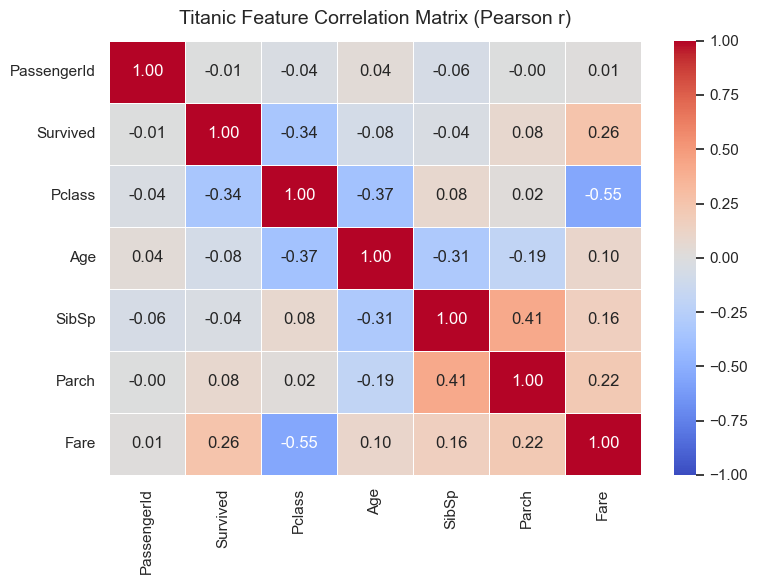

In [9]:
# Compute Pearson correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt='.2f', 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)
plt.title('Titanic Feature Correlation Matrix (Pearson r)', fontsize=14, pad=12)
plt.tight_layout()

# Save plot robustly
plot_dir = '../../outputs/plots' if os.path.exists('../../outputs/plots') else ('outputs/plots' if os.path.exists('outputs/plots') else '.')
os.makedirs(plot_dir, exist_ok=True)
plt.savefig(os.path.join(plot_dir, 'correlation_heatmap.png'), dpi=150)
plt.show()


## 9. Critical Thinking: Correlation vs. Causation in Machine Learning

### What are we doing?
We examine why linear correlation must never be confused with physical causation.

#### The Concept:
A positive correlation between `Fare` and `Survived` ($r = +0.26$) does **not** mean paying more money magically stopped the ship from sinking. Instead, paying a higher fare bought a cabin on upper decks closer to lifeboats and granted early boarding access. The physical mechanism is deck location and evacuation protocol, not the money itself.

#### The ML Implication:
Algorithms learn correlations blindly. If an underlying confounding factor shifts in production, models relying purely on spurious correlation will fail. Always look beyond the $r$ score.


In [10]:
# Mean fare and survival rate by Class
df.groupby('Pclass')[['Fare', 'Survived']].mean().round(3)


,Fare,Survived
Pclass,,
1,84.155,0.630
2,20.662,0.473
3,13.676,0.242


---

## What We Learned
- **Structural Diagnostics**: `shape`, `columns`, and `dtypes` establish feature dimensions and confirm parsing integrity.
- **Memory & Non-Null Auditing**: `df.info()` provides an instant diagnostic of nullity and memory consumption.
- **Five-Number Summaries**: `df.describe()` reveals dispersion, central tendency, and extreme value skew.
- **Nullity & Duplication**: `isnull().sum()` and `duplicated().sum()` expose data quality defects requiring remediation.
- **Cardinality Profiling**: `nunique()` distinguishes constants, categorical candidates, and unique identifiers.
- **Linear Association**: Pearson correlation ($r$) and `sns.heatmap()` uncover initial feature interdependencies.

---

## Important Takeaways
1. **Always run `info()` before modeling**: Catch missing values and text columns early before algorithms fail.
2. **Compare `mean` against `50%` (median)**: A large divergence (as in `Fare`: mean 32.2 vs median 14.4) is an immediate signature of skewness and outliers.
3. **Correlation only measures linear relationships**: Non-linear associations (like $y = x^2$) can have $r \approx 0$ despite strong predictive dependence.
4. **Correlation does not imply causation**: Do not mistake correlation for actionable intervention.

---

## Common Mistakes
1. **Feeding raw text columns into Scikit-Learn**: Columns with `dtype == 'object'` cause crashes if not encoded.
2. **Ignoring missingness percentages**: Blindly imputing a feature that is 80% missing introduces artificial noise.
3. **Leaving unique ID columns in the feature matrix**: Identifiers (like `PassengerId`) cause overfitting if treated as features.
4. **Assuming $r = 0$ means features are independent**: Pearson correlation only detects *linear* relationships.

---

## Final Mental Model

```text
┌────────────────────────────────────────────────────────────────────────┐
│                   DATA UNDERSTANDING AUDIT STACK                       │
└────────────────────────────────────────────────────────────────────────┘
          │
          ├──► 1. Structural Checks     : shape, columns, dtypes
          ├──► 2. Integrity & Health    : info(), isnull().sum(), duplicated().sum()
          ├──► 3. Statistical Profiling : describe(include='all'), nunique()
          └──► 4. Feature Relationships : corr(), sns.heatmap()
```
